# Detector de emociones

# Luis Gonzalez 2024-0509
# Robert Yarel Zapata 2024-1020
# Eimy Genao 2024-0543

Descargar opencv e importacion de modelo

In [ ]:
pip install fer==22.5.0

In [ ]:
!pip install opencv-python-headless==4.10.0.84 numpy matplotlib --quiet
print("OpenCV instalado correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.1 MB/s eta 0:00:00
OpenCV instalado correctamente.


Seleccion del video

In [ ]:
from google.colab import files

uploaded = files.upload()
video_path = list(uploaded.keys())[0]
print("Archivo subido correctamente:", video_path)


Saving videoprueba.mp4 to videoprueba.mp4
Archivo subido correctamente: videoprueba.mp4


Deteccion de rostros mediante camara o video

<IPython.core.display.Javascript object>

Foto capturada: foto.jpg


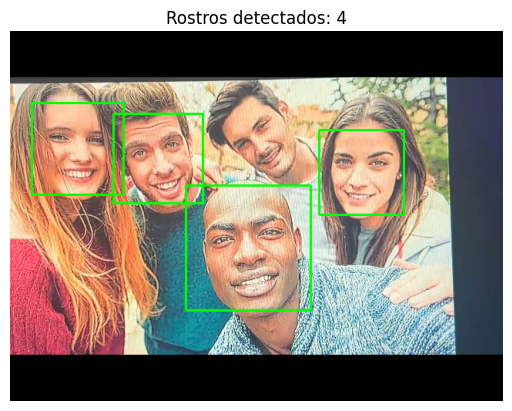

In [ ]:
!pip install opencv-python-headless==4.10.0.84 numpy matplotlib --quiet
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2, numpy as np, matplotlib.pyplot as plt, os

def tomar_foto(filename='foto.jpg', quality=0.9):
    js = Javascript('''
        async function tomarFoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Tomar foto';
            div.appendChild(capture);
            document.body.appendChild(div);
            const video = document.createElement('video');
            video.style.display = 'block';
            document.body.appendChild(video);
            const stream = await navigator.mediaDevices.getUserMedia({video:true});
            video.srcObject = stream;
            await video.play();
            await new Promise(r=>capture.onclick=r);
            const c=document.createElement('canvas');
            c.width=video.videoWidth;c.height=video.videoHeight;
            c.getContext('2d').drawImage(video,0,0);
            stream.getVideoTracks()[0].stop();
            video.remove();div.remove();
            return c.toDataURL('image/jpeg',quality);
        }
    ''')
    display(js)
    data = eval_js('tomarFoto({})'.format(quality))
    with open(filename,'wb') as f:
        f.write(b64decode(data.split(',')[1]))
    return filename

filename = tomar_foto()
print("Foto capturada:", filename)

img = cv2.imread(filename)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
faces = face_cascade.detectMultiScale(gray, 1.1, 5)

for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f"Rostros detectados: {len(faces)}")
plt.show()


Deteccion de emociones

In [ ]:
from fer import FER
import cv2

detector = FER(mtcnn=True)
img = cv2.imread("/content/foto.jpg")
result = detector.detect_emotions(img)
print(result)

Expected: ['input_1']
Received: inputs=Tensor(shape=(7, 64, 64))
  warnings.warn(msg)



[{'box': [1187, 652, 236, 314], 'emotions': {'angry': 0.02, 'disgust': 0.0, 'fear': 0.03, 'happy': 0.95, 'sad': 0.0, 'surprise': 0.0, 'neutral': 0.0}}, {'box': [456, 572, 224, 324], 'emotions': {'angry': 0.01, 'disgust': 0.0, 'fear': 0.0, 'happy': 0.98, 'sad': 0.0, 'surprise': 0.0, 'neutral': 0.0}}, {'box': [960, 369, 234, 296], 'emotions': {'angry': 0.0, 'disgust': 0.0, 'fear': 0.0, 'happy': 1.0, 'sad': 0.0, 'surprise': 0.0, 'neutral': 0.0}}, {'box': [130, 642, 219, 311], 'emotions': {'angry': 0.1, 'disgust': 0.0, 'fear': 0.11, 'happy': 0.75, 'sad': 0.0, 'surprise': 0.04, 'neutral': 0.0}}, {'box': [737, 586, 229, 292], 'emotions': {'angry': 0.0, 'disgust': 0.0, 'fear': 0.0, 'happy': 1.0, 'sad': 0.0, 'surprise': 0.0, 'neutral': 0.0}}, {'box': [773, 93, 224, 261], 'emotions': {'angry': 0.0, 'disgust': 0.0, 'fear': 0.0, 'happy': 1.0, 'sad': 0.0, 'surprise': 0.0, 'neutral': 0.0}}, {'box': [170, 52, 218, 253], 'emotions': {'angry': 0.0, 'disgust': 0.0, 'fear': 0.0, 'happy': 1.0, 'sad': 0.0

In [ ]:
for face in result:
    emociones = face["emotions"]
    emocion_principal = max(emociones, key=emociones.get)
    print("Emoción principal:", emocion_principal, "-", emociones[emocion_principal])

Emoción principal: happy - 0.82


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

INFO:fer:30.00 fps, 1362 frames, 45.40 seconds
INFO:fer:Making directories at output
  0%|          | 0/1362 [00:00<?, ?frames/s]WARNING:py.warnings:/usr/local/lib/python3.12/dist-packages/keras/s

Columnas del DataFrame:
Index(['box', 'angry', 'disgust', 'fear', 'happy', 'sad', 'surprise',
       'neutral'],
      dtype='object')

Promedio de emociones detectadas:
angry       0.046725
disgust     0.002526
fear        0.064178
happy       0.009626
sad         0.213003
surprise    0.001542
neutral     0.660815
dtype: float64

Archivo 'emociones_promedio.csv' guardado correctamente.


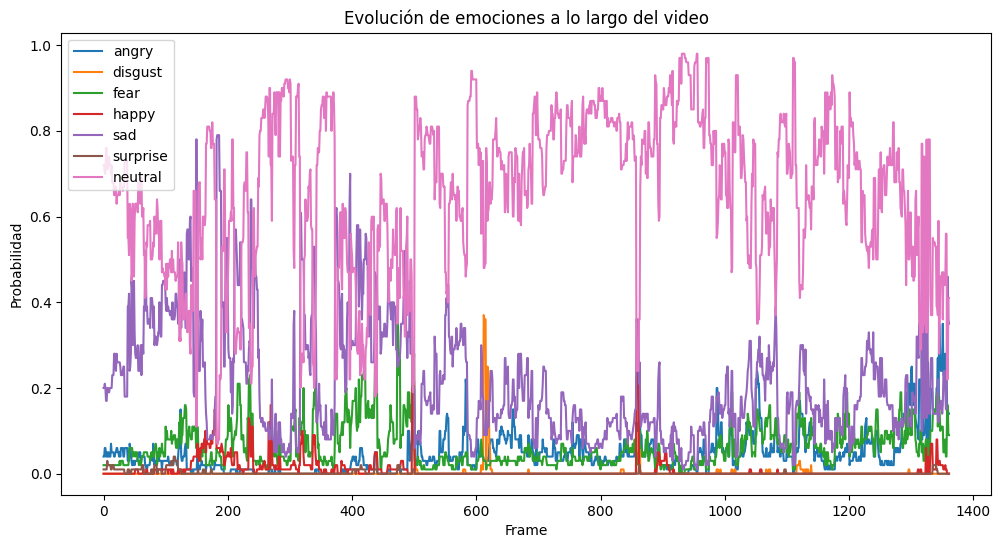

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from fer import Video, FER
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

# Parche
cv2.waitKey = lambda x=None: 0

detector = FER(mtcnn=True)
video_path = "/content/videoprueba.mp4"

video = Video(video_path)
results = video.analyze(detector, display=False, save_video=False, annotate_frames=False)

# Convertir resultados a DataFrame
df = video.to_pandas(results)
print("Columnas del DataFrame:")
print(df.columns)

# Filtrar columnas de emociones
emotion_columns = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
df_emotions = df[emotion_columns].copy()

# Promedio de emociones
emotion_mean = df_emotions.mean()
print("\nPromedio de emociones detectadas:")
print(emotion_mean)


emotion_mean.to_csv("emociones_promedio.csv", header=True)
print("\nArchivo 'emociones_promedio.csv' guardado correctamente.")

# Grafica
df_emotions.plot(figsize=(12,6))
plt.title("Evolución de emociones a lo largo del video")
plt.xlabel("Frame")
plt.ylabel("Probabilidad")
plt.show()

from google.colab import files
files.download("emociones_promedio.csv")

Deteccion mediante video


In [ ]:
# Modelos
!wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
!wget -q https://github.com/opencv/opencv_3rdparty/raw/cv/face_landmark_model/res10_300x300_ssd_iter_140000_fp16.caffemodel
print("Modelos descargados correctamente")

Modelos descargados correctamente


In [ ]:
import cv2
import numpy as np
from fer import FER

# Detector de emociones
detector = FER(mtcnn=True)

# Abrir
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise ValueError("No se pudo abrir el video.")

# Propiedades del video
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Configurar video de salida
output_path = "video_emociones.mp4"
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_num = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # Detectar emociones en el frame
    detections = detector.detect_emotions(frame)

    # Dibujar cada rostro y emoción
    for d in detections:
        (x, y, w, h) = d["box"]
        emotions = d["emotions"]

        # Determinar emoción dominante
        max_emotion = max(emotions, key=emotions.get)
        score = emotions[max_emotion]

        # Dibujar cuadro del rostro
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

        # Texto de la emoción
        text = f"{max_emotion} ({score:.2f})"
        cv2.putText(frame, text, (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    out.write(frame)
    frame_num += 1

cap.release()
out.release()

print("Procesamiento finalizado.")
print("Video generado:", output_path)


Expected: ['input_1']
Received: inputs=Tensor(shape=(5, 64, 64))
  warnings.warn(msg)

Expected: ['input_1']
Received: inputs=Tensor(shape=(5, 64, 64))
  warnings.warn(msg)

Expected: ['input_1']
Received: inputs=Tensor(shape=(6, 64, 64))
  warnings.warn(msg)

Expected: ['input_1']
Received: inputs=Tensor(shape=(7, 64, 64))
  warnings.warn(msg)

Expected: ['input_1']
Received: inputs=Tensor(shape=(4, 64, 64))
  warnings.warn(msg)



Procesamiento finalizado.
Video generado: video_emociones.mp4


In [ ]:
# ============================================
#   INSTALACIÓN
# ============================================
!pip install fer==22.5.0 mtcnn opencv-python-headless tqdm pandas --quiet

import cv2
import numpy as np
from fer import FER
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import os
from google.colab import files
from ipywidgets import VBox, HBox, FileUpload, Button, HTML, Output, FloatProgress

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"   # Forzar CPU



#   INTERFAZ
estilos = """
<h1 style='color:#00eaff; font-size:55px; text-shadow:0px 0px 20px #00eaff; text-align:center'>
Detector de Emociones Ultra Neón
</h1>

<p style='font-size:22px; color:#00ffcc; text-shadow:0px 0px 12px #00ffcc; text-align:center'>
Analiza emociones en video con gráficos avanzados, visuales neón y barra de progreso en tiempo real.
</p>

<div style='background:#0a0f1f; padding:25px; border-radius:20px;
           border:3px solid #00eaff; box-shadow:0px 0px 30px #00eaff'>
<b style='color:#00eaff; font-size:22px;'>1. Subir video</b>
</div>
"""

titulo = HTML(estilos)

upload_widget = FileUpload(accept='.mp4,.avi,.mov', multiple=False)

process_button = Button(
    description="INICIAR PROCESAMIENTO",
    button_style='info',
    layout={'width':'300px','height':'55px'}
)

output_area = Output()

panel = VBox([
    titulo,
    upload_widget,
    HTML("<br><b style='color:#00ffcc; font-size:20px'>2. Procesamiento:</b><br>"),
    process_button,
    output_area
])

display(panel)



#   GUARDAR VIDEO
def save_uploaded(uploaded):
    file_name = list(uploaded.keys())[0]
    file_path = f"/content/{file_name}"
    with open(file_path, "wb") as f:
        f.write(uploaded[file_name]['content'])
    return file_path



#   ANALIZAR VIDEO + BARRA DE PROGRESO
def analyze_video(input_path, output_path, progress_bar, status_html):

    detector = FER(mtcnn=True)
    cap = cv2.VideoCapture(input_path)

    fps = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

    emotion_data = []

    for i in range(frames):
        ret, frame = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = detector.detect_emotions(rgb)

        frame_emotions = {"frame": i}

        for r in results:
            (x, y, w, h) = r["box"]
            emotions = r["emotions"]
            top_emotion = max(emotions, key=emotions.get)

            for emo, val in emotions.items():
                frame_emotions[emo] = val

            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 255, 0), 3)
            cv2.putText(frame, top_emotion, (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.1, (255, 255, 0), 3)

        for e in ['angry','disgust','fear','happy','sad','surprise','neutral']:
            if e not in frame_emotions:
                frame_emotions[e] = 0

        emotion_data.append(frame_emotions)
        out.write(frame)

        # ACTUALIZAR BARRA
        progress_bar.value = (i + 1) / frames

        # Texto de estado
        status_html.value = f"""
        <p style='color:#00eaff; font-size:18px'>
        Procesando frame {i+1} / {frames}…
        </p>
        """

    cap.release()
    out.release()
    return pd.DataFrame(emotion_data)



#   BOTÓN → PROCESAR
def on_process_clicked(b):
    output_area.clear_output(wait=True)

    with output_area:
        if len(upload_widget.value) == 0:
            print("Sube un video primero.")
            return

        print("Guardando video…")
        input_path = save_uploaded(upload_widget.value)
        output_path = "/content/video_emociones.mp4"

        # ======= BARRA DE PROGRESO (SIEMPRE APARECE) =======
        progress_bar = FloatProgress(
            value=0,
            min=0,
            max=1,
            bar_style='info',
            layout={'width': '60%'}
        )

        display(HTML("<h3 style='color:#00eaff'>Procesando video…</h3>"))
        display(progress_bar)

        # ======= FORZAR REFRESCO =======
        import time
        time.sleep(0.3)

        # ======= ANALIZAR VIDEO =======
        df = analyze_video(input_path, output_path, progress_bar)

        print("\nVideo procesado.")

        from IPython.display import Video
        display(HTML("<h3 style='color:#00ffcc'>Video con emociones detectadas:</h3>"))
        display(Video(output_path, embed=True))

        # CSV
        df.to_csv("emociones_por_frame.csv", index=False)
        files.download("emociones_por_frame.csv")

        # ======= Gráfico promedio =======
        plt.figure(figsize=(12,5))
        df[['angry','disgust','fear','happy','sad','surprise','neutral']].mean().plot(kind='bar')
        plt.title("Promedio de emociones detectadas")
        plt.ylabel("Intensidad")
        plt.grid(axis="y")
        plt.show()

        # ======= Gráfico evolución =======
        plt.figure(figsize=(14,6))
        for e in ['angry','disgust','fear','happy','sad','surprise','neutral']:
            plt.plot(df['frame'], df[e], label=e)

        plt.legend()
        plt.title("Evolución de emociones por frame")
        plt.xlabel("Frame")
        plt.ylabel("Intensidad")
        plt.show()

        print("Proceso completado.")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.1 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':

